In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('matlab.mplstyle')

In [8]:
x = [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 38]

# KTY +-5%
y1_trend = [567.4, 571.7, 576.0, 580.6, 585.2, 589.8, 594.4, 599.0, 603.6, 608.2, 612.8, 617.4, 622.0, 626.8, 631.6, 636.4, 641.2, 650.8, 660.4]
y1_min = [539, 543, 547, 551, 555, 560, 564, 568, 572, 577, 581, 585, 590, 594, 599, 603, 607, 616, 625]
y1_max = [596, 600, 605, 609, 614, 619, 623, 628, 633, 637, 642, 647, 652, 657, 662, 666, 671, 681, 691]

# PT1000
y2_trend = [1070, 1074, 1078, 1082, 1086, 1090, 1093, 1097, 1101, 1105, 1109, 1113, 1117, 1121, 1124, 1128, 1132, 1140, 1148]
y2_min = [1069, 1073, 1077, 1081, 1085, 1089, 1092, 1096, 1100, 1104, 1108, 1112, 1116, 1120, 1123, 1127, 1131, 1139, 1147]
y2_max = [1071, 1075, 1079, 1083, 1087, 1091, 1094, 1098, 1102, 1106, 1110, 1114, 1118, 1122, 1125, 1129, 1133, 1141, 1149]

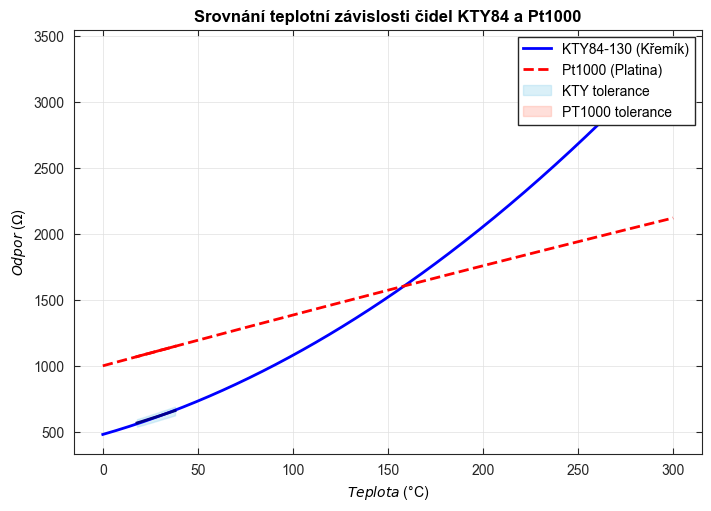

In [17]:
# Definice teplotního rozsahu (od -40 °C do 300 °C)
T = T = np.arange(0, 301, 1)

## 1. VÝPOČET PRO KTY84-130
R_ref_kty = 1000      # Nominální odpor při referenční teplotě [Ohm]
T_ref_kty = 100       # Referenční teplota [°C]
T_i = 250             # Bod zvratu [°C]

A_kty = 7.874e-3
B_kty = 1.874e-5
D_kty = -1.5e-6           

R_kty = np.zeros(np.size(T))

for i in range(len(T)):
    delta_T = T[i] - T_ref_kty
    if T[i] <= T_i:
        R_kty[i] = R_ref_kty * (1 + A_kty * delta_T + B_kty * delta_T**2)
    else:
        delta_Ti = T[i] - T_i
        R_kty[i] = R_ref_kty * (1 + A_kty * delta_T + B_kty * delta_T**2 + D_kty * delta_Ti**2)


## 2. VÝPOČET PRO Pt1000 (dle IEC 60751)
R0_pt = 1000          # Odpor při 0 °C [Ohm]
A_pt = 3.9083e-3
B_pt = -5.775e-7
C_pt = -4.183e-12     # Koeficient C se uplatňuje pouze pro T < 0 °C

R_pt = np.zeros(np.size(T))

for i in range(len(T)):
    if T[i] >= 0:
        # Rovnice pro kladné teploty
        R_pt[i] = R0_pt * (1 + A_pt * T[i] + B_pt * T[i]**2)
    else:
        # Rovnice pro záporné teploty
        R_pt[i] = R0_pt * (1 + A_pt * T[i] + B_pt * T[i]**2 + C_pt * (T[i] - 100) * T[i]**3)


## 3. VYKRESLENÍ GRAFU
plt.fig = plt.subplots(figsize=(7,5), layout='constrained')

plt.plot(T, R_kty+80, 'b-', linewidth = 2, label = 'KTY84-130 (Křemík)')
plt.plot(T, R_pt, 'r--', linewidth = 2, label = 'Pt1000 (Platina)')

plt.fill_between(x, y1_min, y1_max, color="skyblue", alpha=0.3, label="KTY tolerance")
plt.plot(x, y1_trend, color="darkblue", linewidth=2)
plt.fill_between(x, y2_min, y2_max, color="tomato", alpha=0.2, label="PT1000 tolerance")
plt.plot(x, y2_trend, color="red", linewidth=2)

# Formátování grafu
plt.title('Srovnání teplotní závislosti čidel KTY84 a Pt1000')
plt.xlabel('$Teplota$ (°C)')
plt.ylabel('$Odpor$ ($\Omega$)')
#plt.xlim(0,50)
plt.legend()
plt.show()